# Project 5: Discover Topics in Text — Can We Group Documents by Topic?

**Student:** Mohammad Tamim Hamkar

## Step 1 — Import Libraries and Setup

I imported the Python libraries needed to load and explore the 20 Newsgroups dataset, convert text into numerical features using TF-IDF, perform K-Means clustering, analyze the clusters, and use PCA to visualize the results.

In [1]:
# Import All Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 — Load and Explore the 20 Newsgroups Dataset

I loaded the 20 Newsgroups dataset using Scikit-learn. I then explored the number of documents, the number and names of the categories, and a few example documents to better understand the text data before clustering.

In [2]:
# Load and Explore the 20 Newsgroups Dataset

newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    random_state=RANDOM_STATE
)

documents = newsgroups.data
target = newsgroups.target
category_names = newsgroups.target_names

print("20 Newsgroups dataset loaded successfully.")
print("Number of Documents:", len(documents))
print("Number of Categories:", len(category_names))

print("\nCategory Names:")
for i, category in enumerate(category_names):
    print(f"{i}: {category}")

print("\nExample Documents:")
for i in range(3):
    print(f"\n--- Example Document {i + 1} ---")
    print("Category:", category_names[target[i]])
    print(documents[i][:800])

20 Newsgroups dataset loaded successfully.
Number of Documents: 18846
Number of Categories: 20

Category Names:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc

Example Documents:

--- Example Document 1 ---
Category: rec.sport.hockey


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular sea

### Part 1 — Question and Answer

**Question: Why can't we simply give the original text to K-Means?**

K-Means works with numerical data, so it cannot directly understand words or sentences. The text must first be converted into numbers that represent the important words in each document. In this project, I will use TF-IDF to convert the text into numerical features before applying K-Means clustering.

## Step 3 — Text Representation Using TF-IDF

K-Means cannot work directly with text, so I converted the documents into numerical features using TF-IDF. TF-IDF gives more importance to useful words in a document while reducing the importance of very common words. I also removed common English stopwords to make the text representation more meaningful.

In [3]:
# Convert Documents to TF-IDF Features

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(documents)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF completed successfully.")
print("Number of Documents:", X_tfidf.shape[0])
print("Number of Features:", X_tfidf.shape[1])

print("\nSample Feature Names:")
print(feature_names[:30])

TF-IDF completed successfully.
Number of Documents: 18846
Number of Features: 5000

Sample Feature Names:
['00' '000' '01' '02' '03' '04' '040' '05' '06' '07' '08' '09' '0d' '0i'
 '0m' '0q' '0t' '10' '100' '1000' '101' '102' '1024' '1024x768' '104'
 '105' '106' '109' '11' '110']


## Step 4 — Apply K-Means Clustering

I applied K-Means clustering to the TF-IDF features using K = 5. The model groups documents based on similarities in their text features without using the original topic labels. After training the model, I examined how many documents were assigned to each cluster.

In [4]:
# Apply K-Means Clustering with K = 5

kmeans = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_tfidf)

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print("K-Means clustering completed successfully.")
print("Number of Clusters:", kmeans.n_clusters)

print("\nCluster Distribution:")
print(cluster_counts)

K-Means clustering completed successfully.
Number of Clusters: 5

Cluster Distribution:
0     745
1    9661
2    1174
3    3555
4    3711
Name: count, dtype: int64


## Step 5 — Discover and Interpret Cluster Topics

To understand what K-Means discovered, I examined the most important TF-IDF words near the center of each cluster. These common words help identify the main topic or theme represented by each cluster.

In [5]:
# Find the Top Words in Each Cluster

terms = tfidf_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

top_words_per_cluster = {}

print("Top Words in Each Cluster:\n")

for cluster in range(5):
    top_indices = centers[cluster].argsort()[-15:][::-1]
    top_words = terms[top_indices]
    top_words_per_cluster[cluster] = top_words

    print(f"Cluster {cluster}:")
    print(", ".join(top_words))
    print()

Top Words in Each Cluster:

Cluster 0:
god, jesus, christ, believe, bible, faith, christian, christians, sin, people, church, say, does, life, don

Cluster 1:
just, like, edu, new, good, car, know, time, does, don, use, ve, think, used, com

Cluster 2:
game, team, games, year, hockey, players, season, baseball, play, think, player, league, win, don, good

Cluster 3:
thanks, windows, drive, card, know, does, file, use, dos, program, software, help, pc, mail, like

Cluster 4:
people, don, think, just, government, like, know, right, say, time, did, way, said, make, key



## Step 6 — Examine Documents Within Each Cluster

The top words gave an initial idea of the topics discovered by K-Means. To understand the clusters more clearly, I examined sample documents from each cluster. This helps determine whether documents grouped together actually discuss similar topics.

In [6]:
# Display Sample Documents from Each Cluster

for cluster in range(5):
    print("=" * 80)
    print(f"CLUSTER {cluster}")
    print("Top Words:", ", ".join(top_words_per_cluster[cluster][:10]))
    print("=" * 80)

    cluster_indices = np.where(cluster_labels == cluster)[0]

    for j, index in enumerate(cluster_indices[:2]):
        print(f"\nSample Document {j + 1}:")
        print(documents[index][:600].replace("\n", " "))
        print()

    print()

CLUSTER 0
Top Words: god, jesus, christ, believe, bible, faith, christian, christians, sin, people

Sample Document 1:
Let the word of Christ dwell in you richly as you teach and admonish one another with all wisdom, and as you sing psalms, hymns and spiritual songs with gratitude in your hearts to God.  Colossians 3:16  A reminder: These verses are from the New International Version. As with any translation, faithfulness to the original Hebrew and Greek may vary from time to time. If a verse sounds a little off occasionally, compare it with another translation or with the original texts, if you are able to do so.


Sample Document 2:
 Actually, an apostle is someone who is sent.  If you will, mailmen could be called apostles in that sense.  However, with Jesus, they were designated and were given power.  Remember that there were many thousands of people who witnessed what Jesus did.  That didn't make them apostles, though.


CLUSTER 1
Top Words: just, like, edu, new, good, car, know, 

### Cluster Interpretation

After reviewing the top words and sample documents, I found the following general themes:

- **Cluster 0 — Religion / Christianity:** The documents frequently discuss God, Jesus, Christianity, the Bible, faith, and church.
- **Cluster 1 — General / Mixed Discussions:** This is the largest cluster and contains documents from different subjects. It does not have one clear topic.
- **Cluster 2 — Sports:** The documents mainly discuss sports, especially hockey and baseball, including teams, players, games, and seasons.
- **Cluster 3 — Computers / Technology:** The documents discuss computer hardware, Windows, software, drives, cards, files, and other technical topics.
- **Cluster 4 — Politics / Society / General Debate:** This cluster contains broader discussions involving government, rights, society, opinions, and some religious or political debate.

Overall, some clusters have very clear topics, especially religion, sports, and computers. Other clusters are more mixed. This shows that K-Means discovered meaningful patterns in the text, but it did not perfectly separate every document by topic.

## Step 7 — Visualize the Clusters Using PCA

To visualize the K-Means results, I used Principal Component Analysis (PCA) to reduce the TF-IDF features to two dimensions. This makes it possible to display the five clusters on a two-dimensional scatter plot and observe their separation and overlap.

PCA completed successfully.
Original Shape: (18846, 5000)
PCA Shape: (18846, 2)


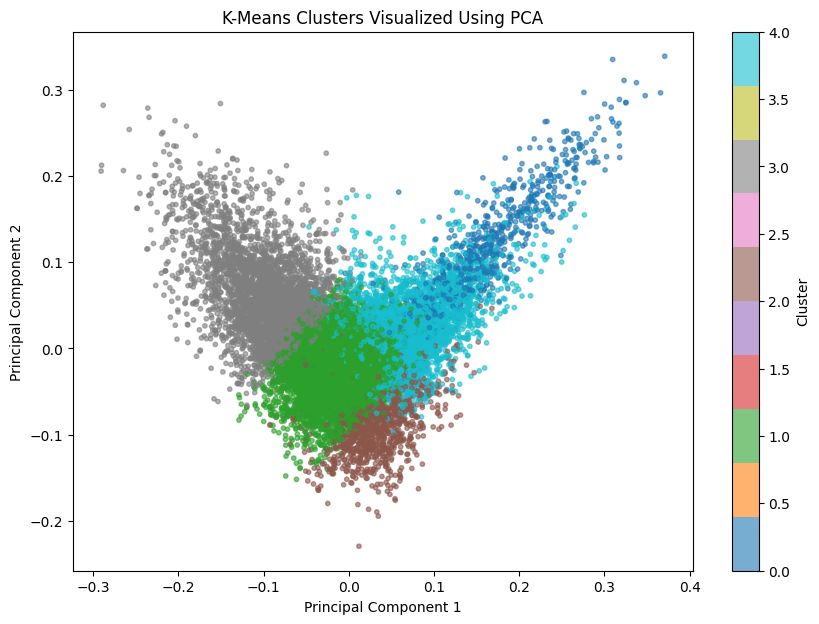

In [7]:
# Reduce TF-IDF Features to Two Dimensions Using PCA

X_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
).fit_transform(X_tfidf.toarray())

print("PCA completed successfully.")
print("Original Shape:", X_tfidf.shape)
print("PCA Shape:", X_pca.shape)

# Visualize K-Means Clusters

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

### PCA Visualization Analysis

The PCA visualization shows that K-Means created some visible grouping among the five clusters. Some clusters extend into more distinct regions of the graph, which suggests that they contain documents with different text patterns.

However, there is also considerable overlap, especially near the center of the plot. This means the clusters are not perfectly separated in two-dimensional space. Since the original TF-IDF data contains 5,000 features and PCA reduces it to only two components, some information is lost during visualization. Overall, the graph shows meaningful structure while also showing that some document topics share similar words and themes.

## Step 8 — Final Analysis Questions

### 1. Why must text be converted into numbers before clustering?

K-Means works with numerical values and calculates distances between data points. It cannot directly understand words or sentences. Therefore, I converted the documents into numerical TF-IDF features before applying K-Means.

### 2. What does TF-IDF represent?

TF-IDF represents how important a word is within a document compared with the full collection of documents. It gives more importance to useful words while reducing the influence of words that appear very frequently across many documents.

### 3. What did K-Means discover in the text data?

K-Means discovered groups of documents with similar word patterns. Some clusters had clear themes, such as religion and Christianity, sports, and computers and technology. Other clusters contained more general or mixed discussions.

### 4. Did documents within the same cluster discuss similar topics?

In several clusters, the documents discussed clearly related topics. For example, Cluster 0 contained many religion-related documents, Cluster 2 focused strongly on sports, and Cluster 3 contained computer and technology discussions. However, Clusters 1 and 4 were more mixed, showing that the clustering was not perfect.

### 5. Which clusters were easiest to interpret?

Clusters 0, 2, and 3 were the easiest to interpret. Cluster 0 contained words such as God, Jesus, Bible, faith, and church. Cluster 2 contained sports-related words such as game, team, hockey, baseball, and players. Cluster 3 contained technology-related words such as Windows, drive, card, file, software, and PC.

### 6. What did the PCA visualization show?

The PCA visualization showed some visible grouping among the five clusters, but there was also considerable overlap, especially near the center. This suggests that some topics have similar text patterns. It also shows that reducing 5,000 TF-IDF features to only two dimensions cannot preserve all of the information in the original data.

### 7. What are some limitations of using K-Means for text clustering?

K-Means groups documents according to numerical similarity and does not truly understand the meaning or context of language. Documents from different topics may use similar words, while documents about the same topic may use different vocabulary. The choice of K also affects the results. Because of these limitations, some clusters were clear while others contained a mixture of topics.

## Step 9 — Conclusion

In this project, I used unsupervised learning to explore topics in the 20 Newsgroups text dataset. I converted the documents into numerical features using TF-IDF and applied K-Means with five clusters. The model discovered several meaningful themes, including religion, sports, and computer technology, while some clusters contained a mixture of topics.

The PCA visualization showed that some clusters had visible separation, but there was also overlap between them. This helped me understand that unsupervised learning can discover useful patterns in text without using predefined topic labels, although the results are not always perfectly separated. Overall, this project gave me a better understanding of how TF-IDF, K-Means, and PCA can be used together to analyze text data.